#Phase 0: Environment Set up

## Environment Instructructions

1.   Save your unique GitHub Access Token in your Colab Secrets files using the exact name -> **gitToken**
2.   Save your unique GitHub Name for revision tracking in your Colab Secrets files using the exact name -> **gitName**
3.   Save your unique GitHub User e-Mail address in your Colab Secrets files using the exact name -> **gitMail**
4.   On **line 26**, ensure you enter the name of the branch you are checking out for changes.

**N.B: NEVER WORK AND MAKE MODIFICATIONS ON THE MAIN BRANCH. ENSURE YOU ARE ALWAYS WORKING ON A SEPERATE BRANCH**


5. To save, commit, and push your current active notebook to your branch repo, run the cell in `Phase X` with your current notebook name and the comment of the commit
6. If you have any issue with the setup cell, contact kChanda.kc@gmail.com

In [1]:
# ============ BOOTSTRAP ============
import subprocess, sys, os
from google.colab import drive, userdata

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load credentials from Colab Secrets
TOKEN = userdata.get('gitToken')
NAME  = userdata.get('gitName')
EMAIL = userdata.get('gitMail')

# 3. Git identity
!git config --global user.name "{NAME}"
!git config --global user.email "{EMAIL}"

# 4. Clone repo (skip if already cloned)
REPO_DIR = '/content/melusi-2025'
if not os.path.exists(REPO_DIR):
    !git clone https://{TOKEN}@github.com/MrChanda/melusi-2025.git {REPO_DIR}
else:
    print("Repo already cloned")

# 5. Switch to your branch and sync with main
os.chdir(REPO_DIR)
!git checkout Lehlogonolo # <-- Enter branch name here
!git fetch origin main
!git merge origin/main -m "Sync with main"

# 6. Install dependencies
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q', '-r',
    os.path.join(REPO_DIR, 'requirements.txt')
])

# 7. Make src/ importable and configure environment
sys.path.insert(0, REPO_DIR)
from src.setup import configure_environment, PATHS, save_and_push
configure_environment()

print("✅ Bootstrap complete — repo at", REPO_DIR)

# ============ IMPORTS ============
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import geopandas as gpd
import earthpy.plot as ep
import contextily as ctx
import laspy
import os
from rasterio.windows import Window

ValueError: mount failed

#Phase 1: Formulate the Question

**Main**

Can a dwelling footprint be reliably extracted from the Melusi drone image, and can the spatial density combined with household survey data predict local population counts?

**Sub Question 1 (Descriptive)**

1.1 What does the imagery cover?

1.2 What is the spectral profile of the dwellings vs non-dwellings?

**Sub Question 2 (Exploratory)**

2.1 Are there spatial patterns in dwelling density across the settlements?

**Sub Question 3 (Predictive)**

3.1 Which image-derived features (pixel intensity, texture, density) are most promising as predictorys of population?

3.2 What survey UID's can be used to link the census data to the Orthophoto

#Phase 2: Read Data & Validate

  ## 2.1 Inspect GeoTIFF

`meta['count']` — number of bands. We expect 3 (Red, Green, Blue). If it's 4, there might be an alpha/transparency band. If it's 1, something's wrong.

`meta['crs']` — the coordinate reference system. This tells us what the coordinates mean. We expect either Lo29 (the South African system the GCPs use) or WGS84/UTM. This is critical for Phase 4 when we overlay GCPs.

`meta['dtype']` — the data type of each pixel. Typically uint8 (values 0–255) for RGB imagery, or uint16 for higher dynamic range. This determines what "bright" and "dark" mean in our histograms later.

`meta['nodata']` — the value used to represent "no data here." Often 0 or 255 in imagery. We need to know this so we can exclude it from our statistics in Phase 5.

`res` — pixel resolution in the CRS units. If the CRS is in metres, we expect something near 0.03 (3 cm). This confirms the resolution matches what the README promised.

`bounds` — the geographic bounding box. Combined with the CRS, this tells us exactly where on Earth this image sits.

In [ ]:
import rasterio

with rasterio.open(PATHS["geotiff"]) as src:
  meta = src.meta
  bounds = src.bounds
  res = src.res

  print("="*50)
  print("Geotiff Metadata")
  print("="*50)
  print(f"Filename:     {os.path.basename(PATHS['geotiff'])}")
  print(f"Driver:       {meta['driver']}")
  print(f"Bands:        {meta['count']}")
  print(f"Width (pixels): {meta['width']:,}")
  print(f"Height (pixels):{meta['height']:,}")
  print(f"Pixel type:     {meta['dtype']}")
  print(f"CRS:            {meta['crs']}")
  print(f"Nodata value:   {meta['nodata']}")
  print()
  print("SPATIAL EXTENT")
  print(f"Resolution:     {res[0]:.4f} x {res[1]:.4f} (CRS units)")
  print(f"Left:           {bounds.left:.4f}")
  print(f"Bottom:         {bounds.bottom:.4f}")
  print(f"Right:          {bounds.right:.4f}")
  print(f"Top:            {bounds.top:.4f}")
  print(f"Width (ground): {bounds.right - bounds.left:.2f} CRS units")
  print(f"Height (ground):{bounds.top - bounds.bottom:.2f} CRS units")
  print()
  print("FILE SIZE")
  size_gb = os.path.getsize(PATHS["geotiff"]) / (1024**3)
  print(f"On disk:        {size_gb:.2f} GB")
  total_pixels = meta['width'] * meta['height'] * meta['count']
  print(f"Total values:   {total_pixels:,}")

### GeoTIFF Metadata

#### Basic Information
- **Filename:** Melusi_07032025Tif.tif
- **Driver:** GTiff
- **Bands:** 4
- **Width (pixels):** 102,730
- **Height (pixels):** 41,815
- **Pixel type:** uint8
- **CRS:**
  1.   PROJCS["unnamed",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,
  2.   AUTHORITY["EPSG","7030"]],
  3.   AUTHORITY["EPSG","6326"]],
  4.   PRIMEM["Greenwich",0],
  5.   UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],
  6.   AUTHORITY["EPSG","4326"]],
  7.   PROJECTION["Transverse_Mercator_South_Orientated"],
  8.   PARAMETER["latitude_of_origin",0],
  9.   PARAMETER["central_meridian",0],
  10.   PARAMETER["scale_factor",1],
  11.   PARAMETER["false_easting",0],
  12.   PARAMETER["false_northing",0],
  13.   UNIT["metre",1],
  14.   AXIS["Easting",WEST],
  15.   AXIS["Northing",SOUTH]]

- **Nodata value:** None

#### Spatial Extent
- **Resolution:** 0.0300 x 0.0300 (CRS units)
- **Left:** 87510.2478
- **Bottom:** 2845792.7340
- **Right:** 90592.1478
- **Top:** 2847047.1840
- **Width (ground):** 3081.90 CRS units
- **Height (ground):** 1254.45 CRS units

#### File Size
- **On disk:** 7.03 GB
- **Total values:** 17,182,619,800

## 2.2 Inspect GCP File

We're validating our ancillary data against the primary dataset `checklist item No.6 from The Art of Data Science`.

If the GCPs fall outside the raster, either the CRS is wrong or the data isn't from the same area. Either way, we catch it now.

In [ ]:
import pandas as pd

gcp_cols = ["GCP_ID", "X", "Y", "Z"]
gcp_df = pd.read_csv(
    PATHS["data_raw"] + "GCPs/Melusi2025_GCPs.txt",
    sep="\t",
    header=None,
    names=gcp_cols
)

print("=" * 50)
print("GROUND CONTROL POINTS (corrected)")
print("=" * 50)
print(f"Number of GCPs: {len(gcp_df)}")
print()
print(gcp_df.to_string(index=False))

print()
print("BOUNDS CHECK")
print(f"Raster X range: {bounds.left:.4f} — {bounds.right:.4f}")
print(f"Raster Y range: {bounds.bottom:.4f} — {bounds.top:.4f}")
print()
for _, row in gcp_df.iterrows():
    x_in = bounds.left <= row["X"] <= bounds.right
    y_in = bounds.bottom <= row["Y"] <= bounds.top
    status = "✅ Inside" if (x_in and y_in) else "❌ Outside"
    print(f"{row['GCP_ID']}: X={row['X']:.4f}, Y={row['Y']:.4f} → {status}")

### Ground Control Points

#### Summary
**Number of GCPs:** 4

#### GCP Coordinates

| GCP_ID | X | Y | Z |
|--------|-----------|------------|----------|
| GCP1 | 88094.7740 | 2846141.6312 | 1320.6579 |
| GCP2 | 88109.4940 | 2846126.0802 | 1320.6222 |
| GCP3 | 89985.0501 | 2846716.7700 | 1248.4542 |
| GCP4 | 89201.5640 | 2846413.2587 | 1332.0237 |

#### Bounds Check
- **Raster X range:** 87510.2478 – 90592.1478
- **Raster Y range:** 2845792.7340 – 2847047.1840

#### Validation Results
- ✅ GCP1: X=88094.7740, Y=2846141.6312 → **Inside**
- ✅ GCP2: X=88109.4940, Y=2846126.0802 → **Inside**
- ✅ GCP3: X=89985.0501, Y=2846716.7700 → **Inside**
- ✅ GCP4: X=89201.5640, Y=2846413.2587 → **Inside**

# Phase 3: LiDAR Inspection

`point_count` — total number of 3D points at 3 cm image resolution.

`X/Y range` — should overlap with the GeoTIFF extent. Both are in Lo29, so the numbers should be comparable to the raster bounds we saw earlier.

`Z range` — height values. Should be in the elevations range of the GCP coordinates.

`dimensions` — tells us what information each point carries beyond XYZ.

In [ ]:
lidar_path = PATHS["data_raw"] + "Point_cloud/Melusi_pointcloud_07032025_lo29.las"
print(os.path.exists(lidar_path))

In [ ]:
import laspy

with laspy.open(lidar_path) as las:
    header = las.header

    print("=" * 50)
    print("LIDAR POINT CLOUD METADATA")
    print("=" * 50)
    print(f"Point count:    {header.point_count:,}")
    print(f"Point format:   {header.point_format.id}")
    print(f"Point size:     {header.point_format.size} bytes")
    print(f"Version:        {header.version}")
    print()
    print("SPATIAL EXTENT")
    print(f"X range: {header.mins[0]:.4f} — {header.maxs[0]:.4f}")
    print(f"Y range: {header.mins[1]:.4f} — {header.maxs[1]:.4f}")
    print(f"Z range: {header.mins[2]:.4f} — {header.maxs[2]:.4f}")
    print()
    print("AVAILABLE DIMENSIONS")
    for dim in header.point_format.dimensions:
        print(f"  {dim.name}")

### LiDAR Point Cloud Metadata

#### Basic Information
- **Point count:** 295,677,631
- **Point format:** 0
- **Point size:** 20 bytes
- **Version:** 1.1

#### Spatial Extent
- **X range:** 87500.0710 – 90603.6980
- **Y range:** 2845769.6550 – 2847064.2850
- **Z range:** 1310.9290 – 1409.6900

#### Available Dimensions
- X
- Y
- Z
- intensity
- return_number
- number_of_returns
- scan_direction_flag
- edge_of_flight_line
- classification
- synthetic
- key_point
- withheld
- scan_angle_rank
- user_data
- point_source_id

In [ ]:
import matplotlib.pyplot as plt

with laspy.open(lidar_path) as las:
    chunk = next(las.chunk_iterator(1_000_000))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Z (height) distribution
    axes[0].hist(chunk.z, bins=100, color='steelblue', edgecolor='none')
    axes[0].set_xlabel('Elevation (m)')
    axes[0].set_ylabel('Point count')
    axes[0].set_title('LiDAR Height Distribution (1M point sample)')

    # Intensity distribution
    axes[1].hist(chunk.intensity, bins=100, color='coral', edgecolor='none')
    axes[1].set_xlabel('Intensity')
    axes[1].set_ylabel('Point count')
    axes[1].set_title('LiDAR Intensity Distribution (1M point sample)')

    plt.tight_layout()
    plt.savefig(PATHS["figures"] + "/lidar_distributions.png", dpi=150)
    plt.show()

print(f"Z  — mean: {np.mean(np.array(chunk.z)):.1f}, std: {np.std(np.array(chunk.z)):.1f}")
print(f"Int — mean: {np.mean(np.array(chunk.intensity)):.1f}, std: {np.std(np.array(chunk.intensity)):.1f}")

### LiDAR Point Cloud Statistics

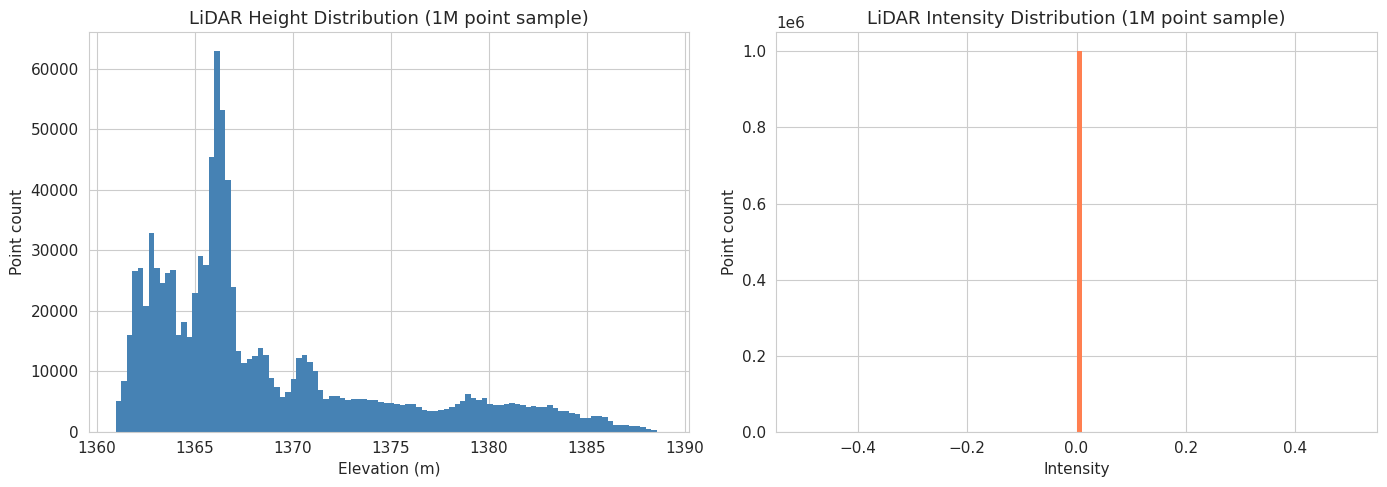

- **Z (elevation)** — mean: 1368.6, std: 6.2
- **Intensity** — mean: 0.0, std: 0.0

In [ ]:
with laspy.open(lidar_path) as las:
    chunk = next(las.chunk_iterator(2_000_000))

    fig, ax = plt.subplots(1, 1, figsize=(14, 8))

    scatter = ax.scatter(
        chunk.x,
        chunk.y,
        c=chunk.z,
        s=0.01,              # tiny dots — we have millions of points
        cmap='terrain',      # green=low, brown=mid, white=high
        vmin=np.percentile(chunk.z, 2),   # clip outliers
        vmax=np.percentile(chunk.z, 98)
    )

    cbar = plt.colorbar(scatter, ax=ax, label='Elevation (m)')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    ax.set_title('LiDAR Surface Model — Elevation Heatmap (2M point sample)')
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.savefig(PATHS["figures"] + "/lidar_elevation_heatmap.png", dpi=150)
    plt.show()

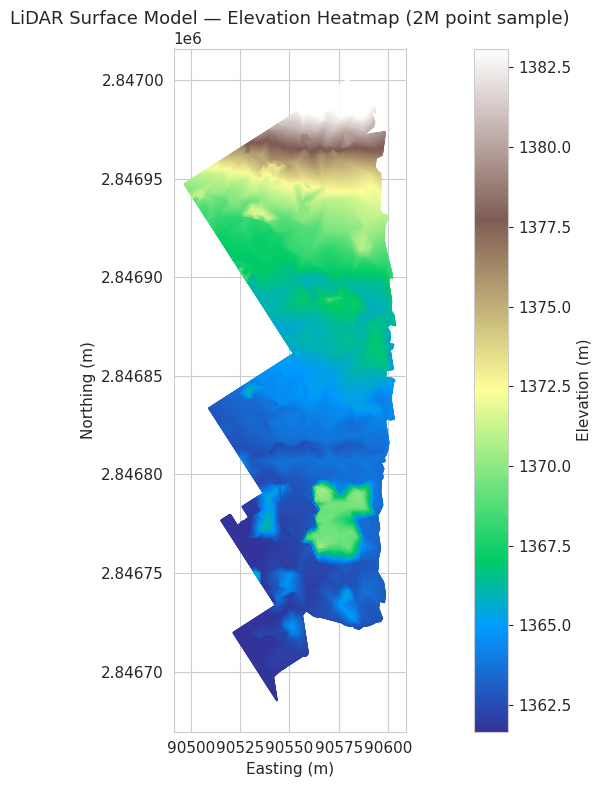

# Phase 4: Print GeoTIFF

In [ ]:
from rasterio.windows import Window

with rasterio.open(PATHS["geotiff"]) as src:
    # Read a 2000x2000 crop from the centre — only bands 1,2,3 (RGB)
    col_start = (src.width // 2) - 1000
    row_start = (src.height // 2) - 1000
    window = Window(col_start, row_start, 2000, 2000)

    rgb = src.read([1, 2, 3], window=window)  # shape: (3, 2000, 2000)
    alpha = src.read(4, window=window)         # shape: (2000, 2000)

    # Stack RGB for display — matplotlib expects (height, width, 3)
    rgb_display = np.moveaxis(rgb, 0, -1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # RGB composite
    axes[0].imshow(rgb_display)
    axes[0].set_title('RGB Orthophoto — Centre Crop (2000×2000 px = 60×60 m)')
    axes[0].axis('off')

    # Alpha band
    axes[1].imshow(alpha, cmap='gray')
    axes[1].set_title('Alpha Band (white=valid, black=nodata)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(PATHS["figures"] + "/geotiff_centre_crop.png", dpi=150)
    plt.show()

    print(f"Alpha band — unique values: {np.unique(alpha)}")
    print(f"Valid pixels: {np.sum(alpha > 0):,} / {alpha.size:,} "
          f"({np.sum(alpha > 0)/alpha.size*100:.1f}%)")

### Alpha Band Analysis

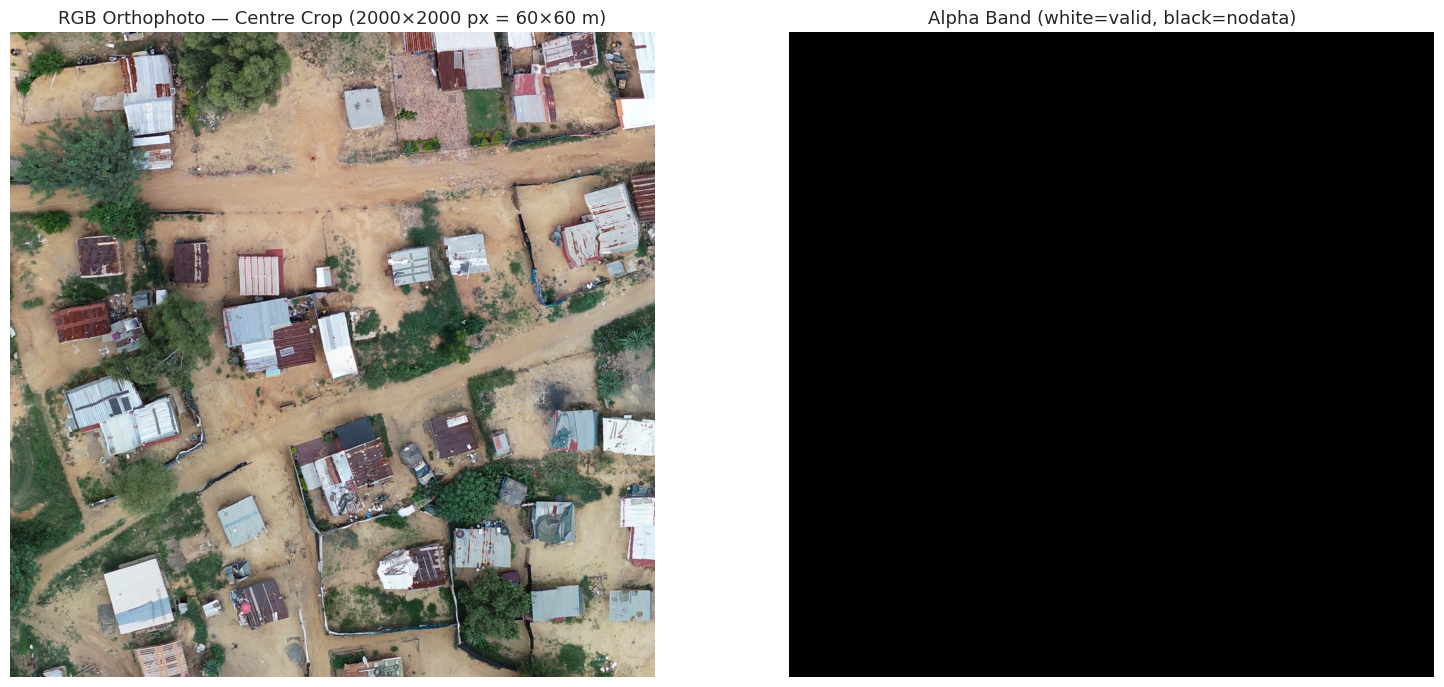

- **Unique values:** [255]
- **Valid pixels:** 4,000,000 / 4,000,000 (100.0%)

# Phase 5: Band Level Inspection

In [ ]:
with rasterio.open(PATHS["geotiff"]) as src:
    # Read the entire image at 1/100th resolution using overviews
    # This reads ~1000x400 pixels instead of 102000x41000
    scale = 100
    small = src.read(
        [1, 2, 3],
        out_shape=(3, src.height // scale, src.width // scale)
    )

    # Check where pixels are empty (all bands near zero)
    brightness = small.mean(axis=0)  # average across RGB
    valid_mask = brightness > 5

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Thumbnail of full image
    axes[0].imshow(np.moveaxis(small, 0, -1))
    axes[0].set_title('Full Orthophoto (downsampled)')
    axes[0].axis('off')

    # Valid data mask
    axes[1].imshow(valid_mask, cmap='RdYlGn')
    axes[1].set_title('Coverage: Green=data, Red=empty')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(PATHS["figures"] + "/raster_overview_coverage.png", dpi=150)
    plt.show()

    pct_valid = valid_mask.sum() / valid_mask.size * 100
    print(f"Valid coverage: {pct_valid:.1f}% of raster extent")

### Coverage Analysis

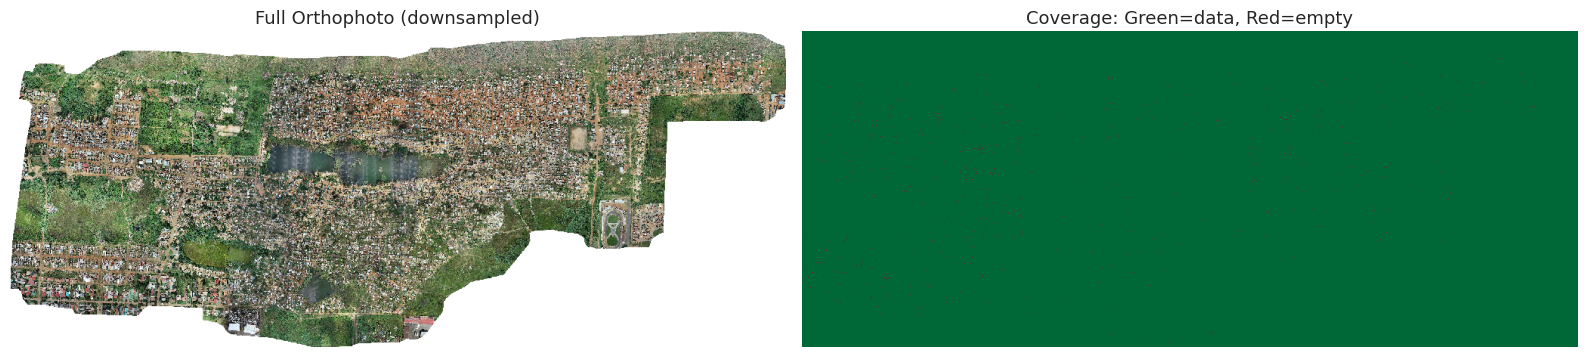

- **Valid coverage:** 99.8% of raster extent

In [ ]:
with rasterio.open(PATHS["geotiff"]) as src:
    scale = 50
    small = src.read(
        [1, 2, 3],
        out_shape=(3, src.height // scale, src.width // scale)
    )

band_names = ['Red', 'Green', 'Blue']
colors = ['red', 'green', 'blue']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
stats = []

for i, (name, color) in enumerate(zip(band_names, colors)):
    band = small[i].flatten()
    band = band[(band > 0) & (band < 255)]  # exclude empty pixels

    axes[i].hist(band, bins=254, color=color, alpha=0.7, edgecolor='none')
    axes[i].set_title(f'{name} Band')
    axes[i].set_xlabel('Pixel Value (0–255)')
    axes[i].set_ylabel('Frequency')

    stats.append({
        'Band': name,
        'Min': band.min(),
        'Max': band.max(),
        'Mean': f"{band.mean():.1f}",
        'Median': f"{np.median(band):.1f}",
        'Std': f"{np.std(band):.1f}",
    })

plt.suptitle('Per-Band Pixel Intensity Distributions (excluding empty pixels)', fontsize=14)
plt.tight_layout()
plt.savefig(PATHS["figures"] + "/band_histograms_clean.png", dpi=150)
plt.show()

print(pd.DataFrame(stats).to_string(index=False))

### Band Statistics

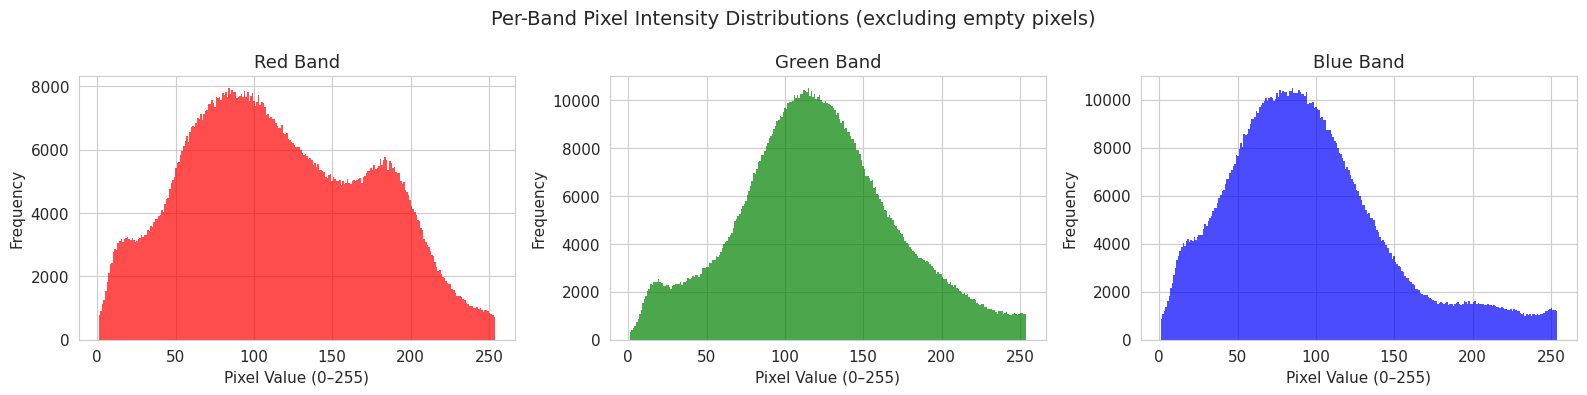

| Band | Min | Max | Mean | Median | Std |
|------|-----|-----|------|--------|-----|
| Red | 1 | 254 | 116.3 | 111.0 | 58.2 |
| Green | 1 | 254 | 120.5 | 119.0 | 50.8 |
| Blue | 1 | 254 | 95.9 | 89.0 | 52.3 |

In [ ]:
with rasterio.open(PATHS["geotiff"]) as src:
    scale = 50
    small = src.read(
        [1, 2, 3],
        out_shape=(3, src.height // scale, src.width // scale)
    )

# Flatten and filter out empty pixels
r = small[0].flatten().astype(float)
g = small[1].flatten().astype(float)
b = small[2].flatten().astype(float)

mask = (r > 0) & (r < 255) & (g > 0) & (g < 255) & (b > 0) & (b < 255)
r, g, b = r[mask], g[mask], b[mask]

# Correlation matrix
corr_df = pd.DataFrame({'Red': r, 'Green': g, 'Blue': b}).corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=0.8, vmax=1.0, ax=axes[0], square=True)
axes[0].set_title('Band Correlation Matrix')

# Scatter: Red vs Blue (most likely to show separation)
sample_idx = np.random.choice(len(r), size=5000, replace=False)
axes[1].scatter(r[sample_idx], b[sample_idx], s=1, alpha=0.3, c='purple')
axes[1].set_xlabel('Red')
axes[1].set_ylabel('Blue')
axes[1].set_title('Red vs Blue Scatter (5000 random pixels)')
axes[1].plot([0, 255], [0, 255], 'k--', alpha=0.3, label='1:1 line')
axes[1].legend()

plt.tight_layout()
plt.savefig(PATHS["figures"] + "/band_correlations.png", dpi=150)
plt.show()

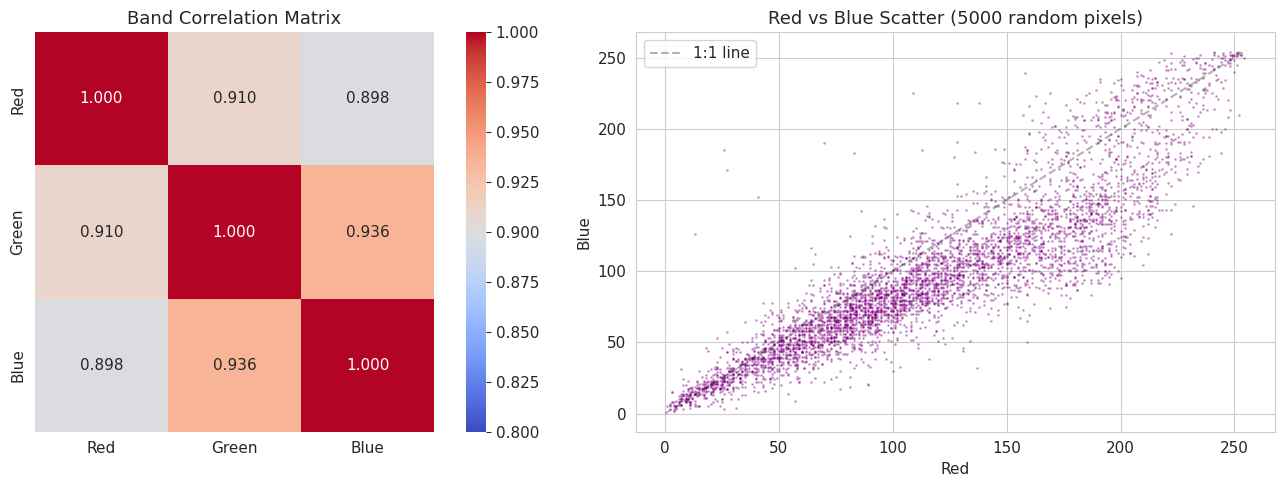

In [ ]:
from rasterio.windows import Window

with rasterio.open(PATHS["geotiff"]) as src:
    col_start = (src.width // 2) - 1000
    row_start = (src.height // 2) - 1000
    window = Window(col_start, row_start, 2000, 2000)
    rgb = src.read([1, 2, 3], window=window).astype(float)

r, g, b = rgb[0], rgb[1], rgb[2]

# Avoid division by zero
total = r + g + b
total[total == 0] = 1

# Three simple indices
brightness = total / 3
excess_green = (2 * g - r - b)                    # highlights vegetation
red_ratio = r / total                               # highlights bare soil

# Threshold brightness to find rooftops (bright metallic surfaces)
roof_mask = brightness > 160

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: RGB + indices
axes[0, 0].imshow(np.moveaxis(rgb.astype(np.uint8), 0, -1))
axes[0, 0].set_title('RGB Original')

axes[0, 1].imshow(brightness, cmap='gray')
axes[0, 1].set_title('Brightness (R+G+B)/3')

axes[0, 2].imshow(excess_green, cmap='RdYlGn', vmin=-100, vmax=100)
axes[0, 2].set_title('Excess Green Index (vegetation)')

# Row 2: Red ratio + masks
axes[1, 0].imshow(red_ratio, cmap='RdYlBu_r', vmin=0.25, vmax=0.45)
axes[1, 0].set_title('Red Ratio R/(R+G+B) (bare soil)')

# Roof detection mask
axes[1, 1].imshow(np.moveaxis(rgb.astype(np.uint8), 0, -1))
roof_overlay = np.zeros((*roof_mask.shape, 4))
roof_overlay[roof_mask] = [1, 0, 0, 0.4]  # red transparent overlay
axes[1, 1].imshow(roof_overlay)
axes[1, 1].set_title(f'Bright Roof Detection (>{160})')

# Vegetation mask
veg_mask = excess_green > 20
axes[1, 2].imshow(np.moveaxis(rgb.astype(np.uint8), 0, -1))
veg_overlay = np.zeros((*veg_mask.shape, 4))
veg_overlay[veg_mask] = [0, 1, 0, 0.4]  # green transparent overlay
axes[1, 2].imshow(veg_overlay)
axes[1, 2].set_title('Vegetation Detection (EGI > 20)')

for ax in axes.flat:
    ax.axis('off')

plt.suptitle('Phase 6b: Simple Thresholding — "Try the Easy Solution"', fontsize=14)
plt.tight_layout()
plt.savefig(PATHS["figures"] + "/thresholding_easy_solution.png", dpi=150)
plt.show()

# Summary statistics
total_pixels = brightness.size
print(f"Total pixels:     {total_pixels:,}")
print(f"Bright roofs:     {roof_mask.sum():,} ({roof_mask.sum()/total_pixels*100:.1f}%)")
print(f"Vegetation:       {veg_mask.sum():,} ({veg_mask.sum()/total_pixels*100:.1f}%)")
print(f"Other (soil/dark):{total_pixels - roof_mask.sum() - veg_mask.sum():,} "
      f"({(total_pixels - roof_mask.sum() - veg_mask.sum())/total_pixels*100:.1f}%)")

italicized text### Thresholding Results

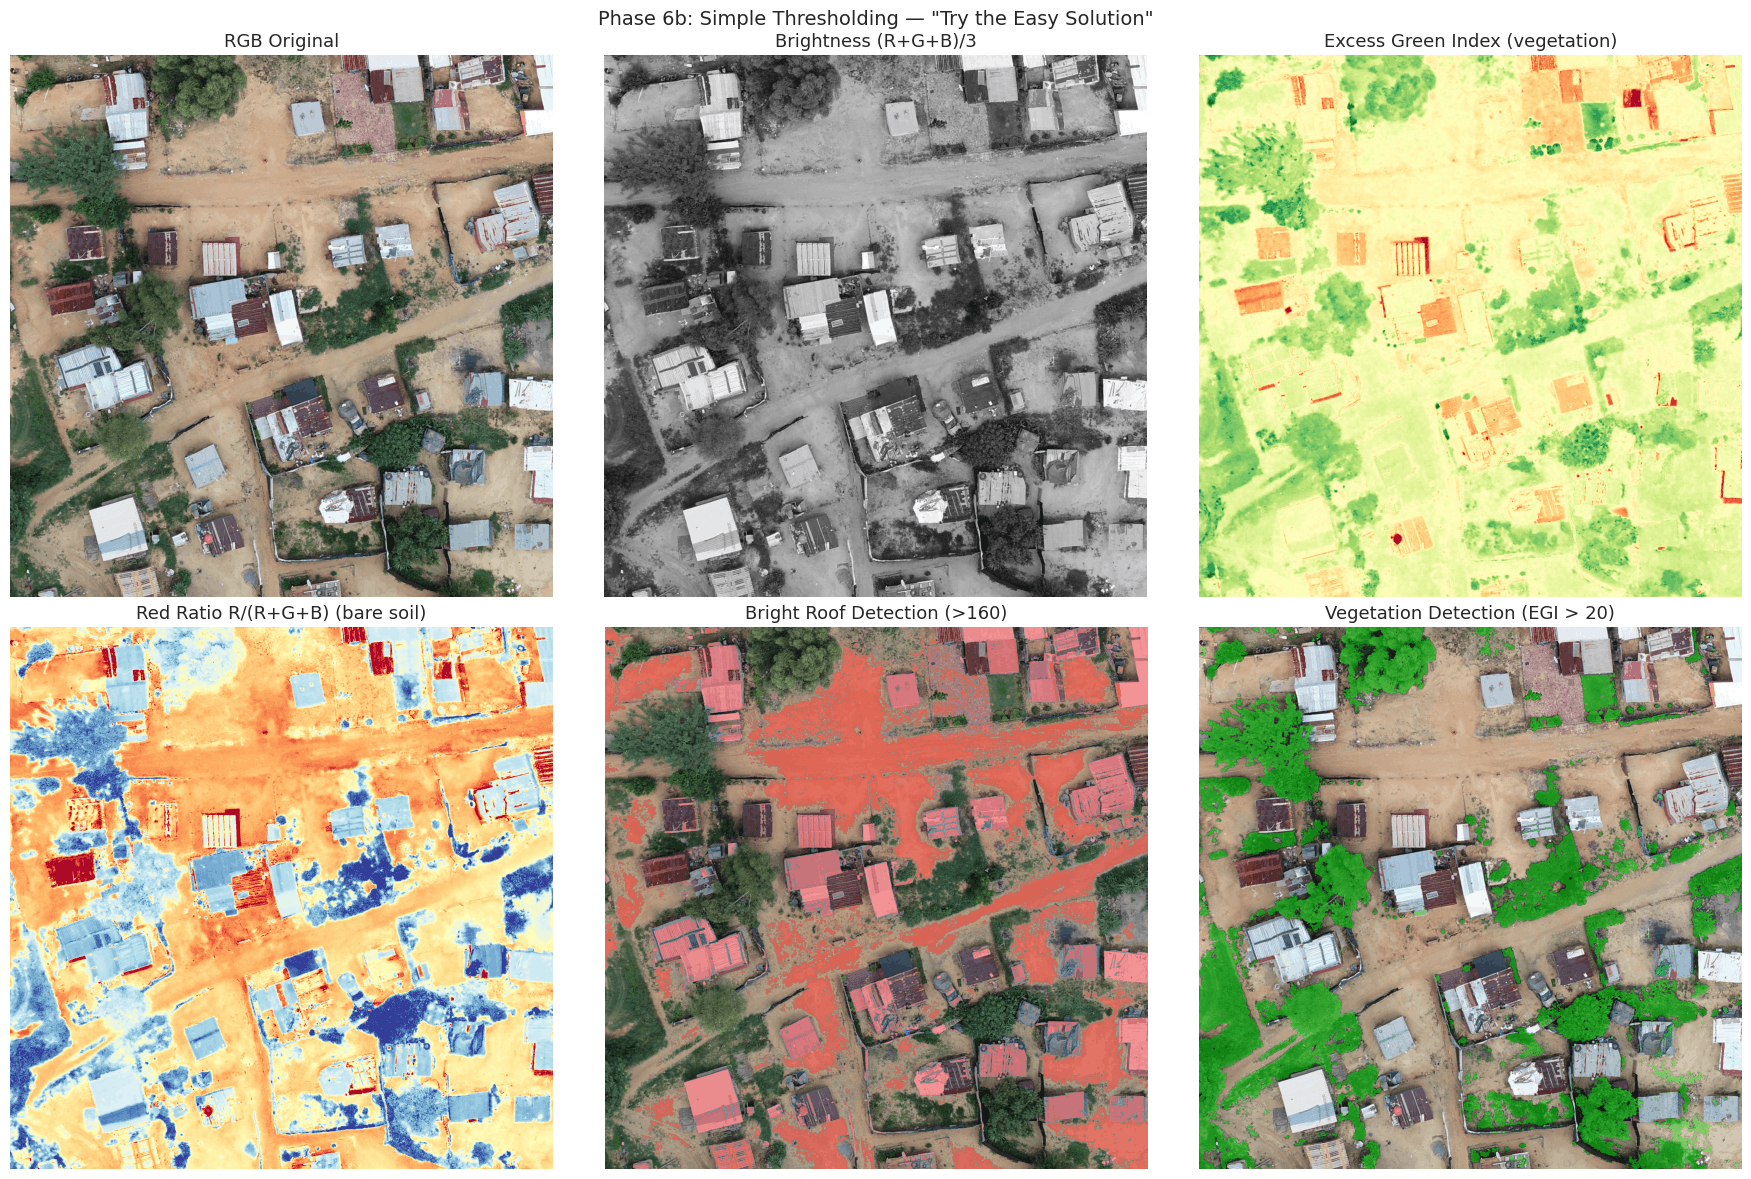

| Category | Count | Percentage |
|----------|-------|------------|
| Total pixels: | 4,000,000 | |
| Bright roofs: | 1,366,124 | (34.2%) |
| Vegetation: | 919,758 | (23.0%) |
| Other (soil/dark): | 1,714,118 | (42.9%) |

# Phase 6: Census Survey Analysis

## Filtering the GRT-I Baseline data to contain the survey response for Melusi

In [2]:
import pandas as pd
import os

# Path to the CSV file
survey_path = PATHS["data_raw"] + "Survey/DataBaseline_v2.csv"

# Check if the file exists
if os.path.exists(survey_path):
    print("File exists ✅")
else:
    print("File not found ❌")

# Read the CSV with semicolon separator and correct encoding
df = pd.read_csv(survey_path, sep=';', encoding='latin1')
df = df[df['sites'] == "Melusi"]

File exists ✅


/tmp/ipykernel_413/4019934204.py:14: DtypeWarning: Columns (13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(survey_path, sep=';', encoding='latin1')


## Checking the dimension of the data and data types of the columns

In [3]:
# Display basic summary
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData types:\n", df.dtypes)

Shape of dataset: (8174, 278)

Columns:
 Index(['Blocks', 'interview__key', 'Longitude', 'Latitude', 'Dwelling_count',
       'hhr_register_roster__id', 'register_members_roster__id', 'Institution',
       'sites', 'dwelling_informant',
       ...
       'Nyaope_heroin_whoonga_unga', 'Cocaine_crack_cat',
       'Methamphetamine_tik_crystal', 'GHB_Ketamine_LSD', 'Sleeping_tablets',
       'Glue_petrol_thinners_sniffing',
       'Benzodiazepines_Valium_diazepam_alprazolam', 'Other.2',
       'ceu_the_informant_type', 'CEU_recommendations,,,,,,,,'],
      dtype='object', length=278)

Data types:
 Blocks                                        float64
interview__key                                 object
Longitude                                      object
Latitude                                       object
Dwelling_count                                float64
                                               ...   
Glue_petrol_thinners_sniffing                  object
Benzodiazepines_Valiu

## Displaying the first 5 rows

In [4]:
print("\nFirst 5 rows:\n", df.head())


First 5 rows:
        Blocks interview__key Longitude   Latitude  Dwelling_count  \
19766    11.0    00-06-09-86  28,12639  -25,72485          1007.0   
19767    11.0    00-06-09-86  28,12639  -25,72485          1007.0   
19768    12.0    00-06-28-22  28,12148  -25,72149          1655.0   
19769    12.0    00-06-28-22  28,12148  -25,72149          1655.0   
19770    12.0    00-06-28-22  28,12148  -25,72149          1655.0   

       hhr_register_roster__id  register_members_roster__id Institution  \
19766                        1                            1          UP   
19767                        1                            2          UP   
19768                        1                            1          UP   
19769                        1                            2          UP   
19770                        1                            3          UP   

        sites dwelling_informant  ... Nyaope_heroin_whoonga_unga  \
19766  Melusi     Dwelling Owner  ...             

## Summary Statistics and missings analysis

In [5]:
print("\nSummary statistics for numeric columns:\n", df.describe())
print("\nMissing values per column:\n", df.isnull().sum())


Summary statistics for numeric columns:
             Blocks  Dwelling_count  hhr_register_roster__id  \
count  8164.000000     8164.000000              8174.000000   
mean      7.194268     1068.992528                 1.008074   
std       3.500930      336.687514                 0.097357   
min       1.000000      619.000000                 1.000000   
25%       4.000000      738.000000                 1.000000   
50%       7.000000     1065.000000                 1.000000   
75%      11.000000     1332.000000                 1.000000   
max      12.000000     1655.000000                 3.000000   

       register_members_roster__id  hhr_refusal_reason  hh_transfer_to  \
count                  8174.000000                 0.0             0.0   
mean                      1.845241                 NaN             NaN   
std                       1.206716                 NaN             NaN   
min                       1.000000                 NaN             NaN   
25%                 

## Some key feactures that tells us info about the population

In [6]:
#Some statistics that can be helpful:
resident_population_df = df[df['is_member_resident'] == "Yes, resident"]
population = resident_population_df["hhr_member_total"].sum()
population_total = df["hhr_member_total"].sum()
print("resident population:", int(population))
print("non-resident + resident  population:", int(population_total))
dwelling_total = df.shape[0]
print("number of dwellings:", int(dwelling_total))
# Count the number of unique blocks
num_unique_blocks = df['Blocks'].nunique()
print("Number of unique blocks:", num_unique_blocks)
num_unique_Longitude_coords = df['Longitude'].nunique()
print("Number of unique Longitude_coords:", num_unique_Longitude_coords)
num_unique_Latitude_coords = df['Latitude'].nunique()
print("Number of unique Latitude_coords:", num_unique_Latitude_coords)

resident population: 21238
non-resident + resident  population: 21486
number of dwellings: 8174
Number of unique blocks: 12
Number of unique Longitude_coords: 14
Number of unique Latitude_coords: 14


## Checking Duplicates and count of unique values per column

In [7]:
#Checking if all rows are unique:
# Count duplicate rows in the entire DataFrame
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)

# If you want to actually see the duplicate rows
duplicate_rows = df[df.duplicated()]
print("Duplicate rows:")
print(duplicate_rows)

#checking the unique values for each column:
unique_counts = df.nunique()
unique_counts

Number of duplicate rows: 7
Duplicate rows:
       Blocks interview__key Longitude   Latitude  Dwelling_count  \
22769    12.0    14-17-93-19  28,12148  -25,72149          1655.0   
22770    12.0    14-17-93-19  28,12148  -25,72149          1655.0   
22771    12.0    14-17-93-19  28,12148  -25,72149          1655.0   
23034     6.0    15-67-52-76  28,11521   -25,7246          1065.0   
28604     4.0    41-96-25-15  28,12675  -25,72045           619.0   
37823     6.0    87-30-00-45  28,11521   -25,7246          1065.0   
40102    12.0    98-45-80-39  28,12148  -25,72149          1655.0   

       hhr_register_roster__id  register_members_roster__id Institution  \
22769                        1                            1          UP   
22770                        1                            2          UP   
22771                        1                            3          UP   
23034                        1                            1          UP   
28604                       

,0
Blocks,12
interview__key,4392
Longitude,14
Latitude,14
Dwelling_count,13
...,...
Glue_petrol_thinners_sniffing,2
Benzodiazepines_Valium_diazepam_alprazolam,1
Other.2,2
ceu_the_informant_type,0


## Distribution of members in a dwelling

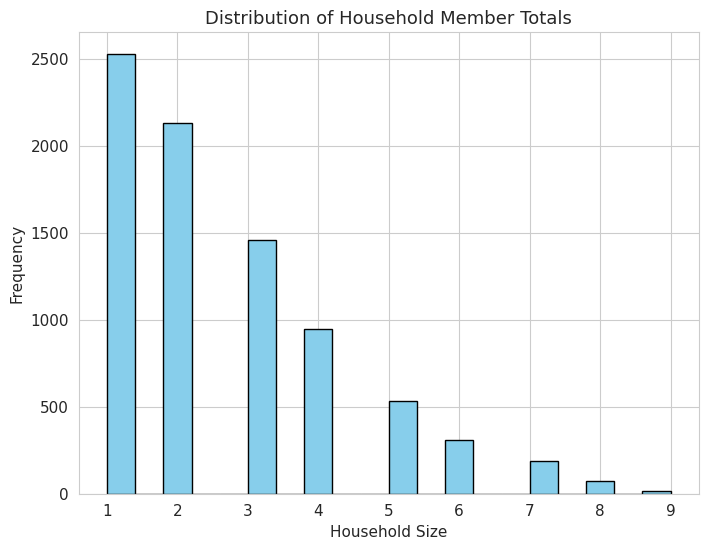

In [8]:
import matplotlib.pyplot as plt

population_total = df["hhr_member_total"]

plt.figure(figsize=(8,6))
plt.hist(population_total, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Household Member Totals")
plt.xlabel("Household Size")
plt.ylabel("Frequency")
plt.show()


# Phase 7: Synthesis

In [ ]:
# Data inventory table
inventory = pd.DataFrame({
    "Dataset": [
        "Orthophoto (GeoTIFF)",
        "Orthophoto (ECW)",
        "Ground Control Points",
        "LiDAR Point Cloud",
        "GRT-I Baseline Survey",
    ],
    "Format": [
        "GeoTIFF (.tif)",
        "ECW (.ecw)",
        "Text (.txt)",
        "LAS (.las)",
        "Excel (.xlsx)",
    ],
    "Size": [
        "7.03 GB (102,730 × 41,815 px × 4 bands)",
        "689 MB",
        "4 points",
        "5.9 GB (295.7M points)",
        "46,112 rows × 269 cols (8,119 Melusi)",
    ],
    "Key Properties": [
        "3cm RGB+Alpha, Lo CRS, uint8, nodata=255",
        "Compressed version of GeoTIFF",
        "Lo29, all 4 within raster bounds, FIXED status",
        "Lo29, unclassified, Z: 1311–1410m, no intensity",
        "Individual-level, no dwelling ID or coordinates",
    ],
    "EDA Status": [
        "✅ Metadata, visual, histograms, correlations, thresholding",
        "⬜ Not inspected (compressed duplicate), used for quick validation",
        "✅ Parsed, bounds-checked",
        "✅ Metadata, Z distribution, elevation heatmap",
        "⚠️ Filtered to Melusi, pending spatial link from Samy",
    ],
})

print(inventory.to_string(index=False))

### Dataset Summary Table

| Dataset | Format | Size | Key Properties | EDA Status |
|---------|--------|------|----------------|------------|
| Orthophoto (GeoTIFF) | GeoTIFF (.tif) | 7.03 GB (102,730 × 41,815 px × 4 bands) | 3cm RGB+Alpha, Lo29 CRS, uint8, nodata=255 | ✅ Metadata, visual, histograms, correlations, thresholding |
| Orthophoto (ECW) | ECW (.ecw) | 689 MB | Compressed version of GeoTIFF | ⬜ Not inspected (compressed duplicate), used for quick validation |
| Ground Control Points | Text (.txt) | 4 points | Lo29, all 4 within raster bounds, FIXED status | ✅ Parsed, bounds-checked |
| LiDAR Point Cloud | LAS (.las) | 5.9 GB (295.7M points) | Lo29, unclassified, Z: 1311–1410m, no intensity | ✅ Metadata, Z distribution, elevation heatmap |
| GRT-I Baseline Survey | Excel (.xlsx) | 46,112 rows × 269 cols (8,119 Melusi) | Individual-level, no dwelling ID or coordinates | ⚠️ Filtered to Melusi, pending spatial link from Samy |

# References

[1] Peng, R.D. and Matsui, E. (2018). The Art of Data Science. Leanpub.

[2] GRT-INSPIRED HDSS Baseline Dataset (2021–2022). Gauteng Research Triangle, University of Pretoria.

[3] Everatt, D., Hugo, J., Palanee-Phillips, T., Barnard, T.G., Madonsela, S. and Mbetse, E. (2025). GRT-INSPIRED Baseline data. University of the Witwatersrand, Johannesburg. https://doi.org/10.71796/wits-figshare.30665075.v1

[4] DJI (2026). Zenmuse L1 Specifications. Retrieved March 16, 2026, from https://www.dji.com/global/zenmuse-l1/specs

#Phase X: Git -push and -Commit

In [ ]:
save_and_push("01_eda.ipynb", "Add Phase 2: Guide Questions")

📋 Copied 01_eda.ipynb into repo
✅ Pushed 01_eda.ipynb to Lehlogonolo
